# 01. groupSHAP Preprocess

UCI Adult (Census Income) データを `census+income.zip` から直接読み込み、カテゴリ列を one-hot encoding します。  
通常 SHAP は one-hot 列ごとの符号付き寄与として見て、群側は one-hot 列の `|SHAP|` を元変数単位で集約して見ます。

## ライブラリインポート

In [1]:
import os
from io import TextIOWrapper
from pathlib import Path
import zipfile

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

/home/kohei/WorkSpace/DS_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## データロード

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
ZIP_PATH = DATA_DIR / "census+income.zip"

COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income",
]


def read_adult_from_zip(zip_path: Path, member_name: str, skiprows: int = 0) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(member_name) as f:
            return pd.read_csv(
                TextIOWrapper(f, encoding="utf-8"),
                names=COLUMNS,
                skiprows=skiprows,
                skipinitialspace=True,
                na_values="?",
            )


train_df = read_adult_from_zip(ZIP_PATH, "adult.data")
test_df = read_adult_from_zip(ZIP_PATH, "adult.test", skiprows=1)
test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

display(train_df.head())
display(test_df.head())
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


train shape: (32561, 15)
test shape: (16281, 15)


## 最低限の前処理

In [3]:
categorical_cols = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country",
]

numeric_cols = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
]

for current_df in [train_df, test_df]:
    for col in current_df.select_dtypes(include=["object", "string"]).columns:
        current_df[col] = current_df[col].str.strip()
    current_df[categorical_cols] = current_df[categorical_cols].fillna("Unknown")

missing_summary = pd.DataFrame({
    "train_missing_ratio": train_df.isna().mean(),
    "test_missing_ratio": test_df.isna().mean(),
}).sort_values("train_missing_ratio", ascending=False)

display(missing_summary.query("train_missing_ratio > 0 or test_missing_ratio > 0"))
display(train_df["income"].value_counts(normalize=True).rename("train_ratio"))
display(test_df["income"].value_counts(normalize=True).rename("test_ratio"))

,train_missing_ratio,test_missing_ratio


income
<=50K    0.75919
>50K     0.24081
Name: train_ratio, dtype: float64

income
<=50K    0.763774
>50K     0.236226
Name: test_ratio, dtype: float64

## one-hot encoding

In [4]:
feature_cols = numeric_cols + categorical_cols

combined_features = pd.concat(
    [
        train_df[feature_cols].assign(_split="train"),
        test_df[feature_cols].assign(_split="test"),
    ],
    ignore_index=True,
)

combined_encoded = pd.get_dummies(
    combined_features,
    columns=categorical_cols,
    dtype=int,
)

train_mask = combined_encoded["_split"] == "train"
X_train = combined_encoded.loc[train_mask].drop(columns="_split").reset_index(drop=True)
X_test = combined_encoded.loc[~train_mask].drop(columns="_split").reset_index(drop=True)
y_train = (train_df["income"] == ">50K").astype(int).reset_index(drop=True)
y_test = (test_df["income"] == ">50K").astype(int).reset_index(drop=True)

feature_groups = {col: [col] for col in numeric_cols}
for col in categorical_cols:
    feature_groups[col] = [encoded_col for encoded_col in X_train.columns if encoded_col.startswith(f"{col}_")]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
display(pd.Series({k: len(v) for k, v in feature_groups.items()}, name="n_columns"))

X_train: (32561, 108)
X_test: (16281, 108)


age                1
fnlwgt             1
education_num      1
capital_gain       1
capital_loss       1
hours_per_week     1
workclass          9
education         17
marital_status     7
occupation        15
relationship       6
race               5
sex                2
native_country    42
Name: n_columns, dtype: int64

## XGBoost ベースライン

In [5]:
baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

baseline_model.fit(X_train, y_train)

test_pred = baseline_model.predict(X_test)
test_proba = baseline_model.predict_proba(X_test)[:, 1]

## ベースライン評価

In [6]:
metrics_df = pd.Series(
    {
        "accuracy": accuracy_score(y_test, test_pred),
        "roc_auc": roc_auc_score(y_test, test_proba),
    },
    name="baseline_score",
).round(4)

display(metrics_df)
print(classification_report(y_test, test_pred, digits=4))

accuracy    0.8765
roc_auc     0.9277
Name: baseline_score, dtype: float64

              precision    recall  f1-score   support

           0     0.8977    0.9461    0.9213     12435
           1     0.7890    0.6513    0.7136      3846

    accuracy                         0.8765     16281
   macro avg     0.8433    0.7987    0.8174     16281
weighted avg     0.8720    0.8765    0.8722     16281



## 通常 SHAP

通常 SHAP は one-hot 列ごとの符号付き寄与として扱います。

In [7]:
X_shap = X_test.copy()
explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer(X_shap)

print("SHAP input shape:", X_shap.shape)
print("SHAP values shape:", shap_values.values.shape)

SHAP input shape: (16281, 108)
SHAP values shape: (16281, 108)


## 通常 SHAP summary plot

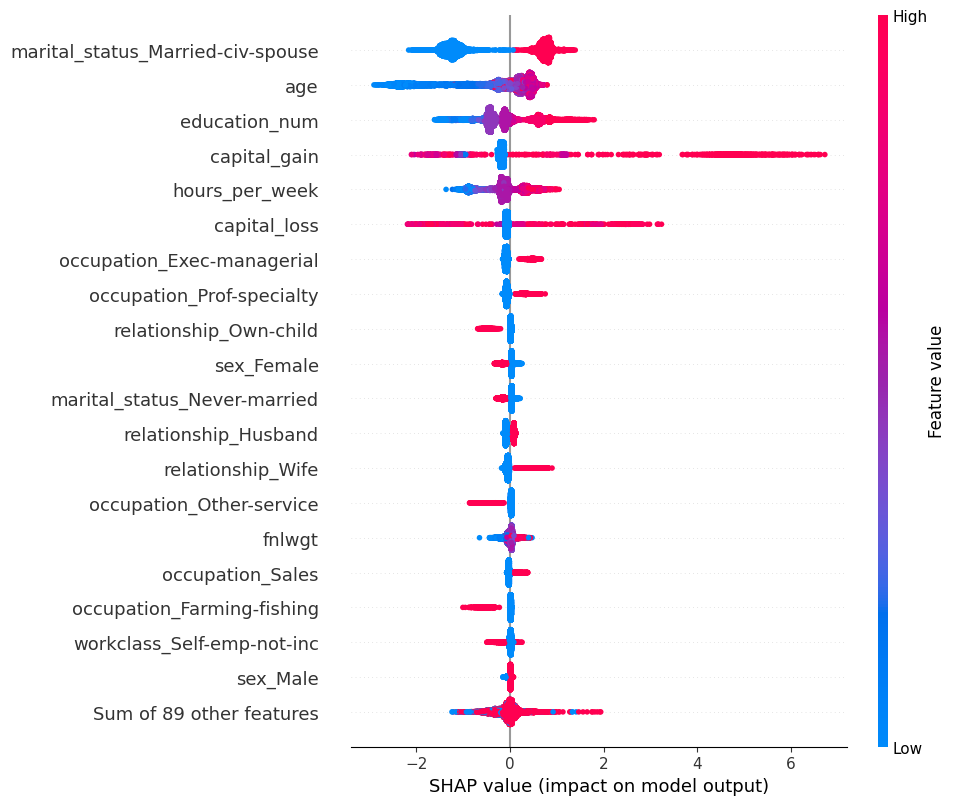

In [8]:
shap.plots.beeswarm(shap_values, max_display=20)

## 通常 SHAP importance bar plot

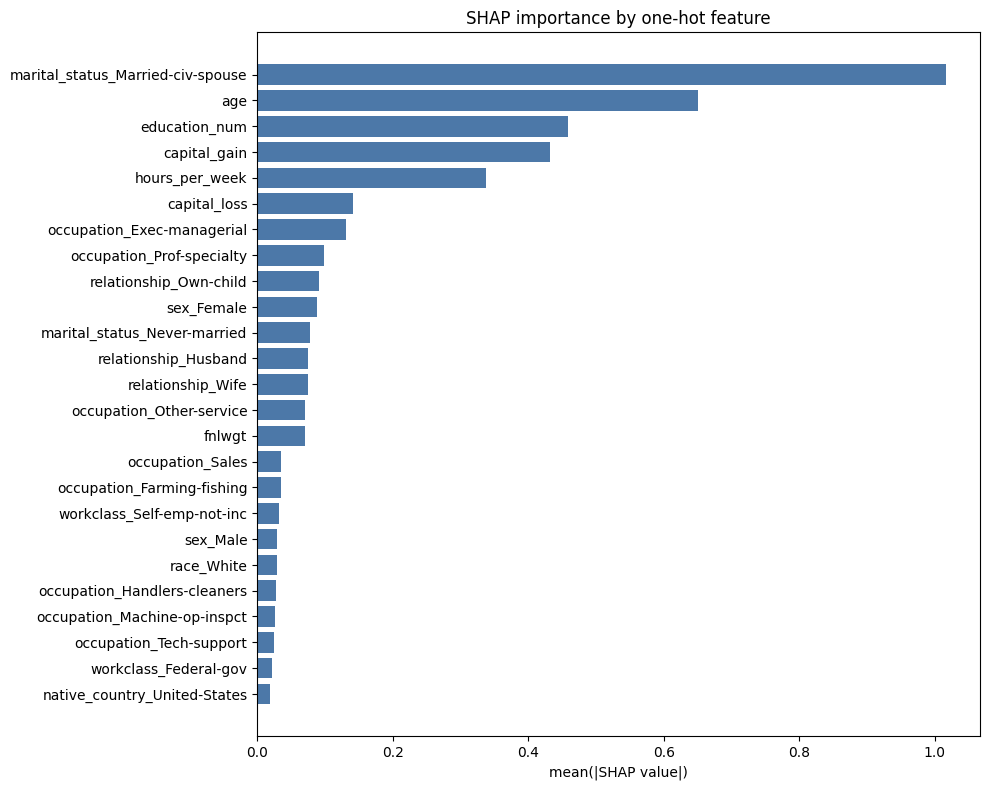

In [9]:
feature_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_shap.columns,
    name="mean_abs_shap",
).sort_values(ascending=False)

top_feature_bar = feature_importance.head(25).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_feature_bar.index, top_feature_bar.values, color="#4C78A8")
ax.set_title("SHAP importance by one-hot feature")
ax.set_xlabel("mean(|SHAP value|)")
ax.set_ylabel("")
plt.tight_layout()

## 群側の absolute aggregation

群側は one-hot 列の `|SHAP|` を元変数単位で足し上げて、カテゴリ変数としての寄与量を見ます。

In [10]:
group_names = list(feature_groups.keys())

group_abs_matrix = np.column_stack([
    np.abs(shap_values.values[:, [X_shap.columns.get_loc(col) for col in feature_groups[group_name]]]).sum(axis=1)
    for group_name in group_names
])

group_importance = pd.Series(
    group_abs_matrix.mean(axis=0),
    index=group_names,
    name="mean_sum_abs_shap",
).sort_values(ascending=False)

display(group_importance)
print("group absolute matrix:", group_abs_matrix.shape)

marital_status    1.116621
age               0.650317
education         0.496090
occupation        0.494982
education_num     0.458770
capital_gain      0.431999
hours_per_week    0.337752
relationship      0.284567
capital_loss      0.141883
sex               0.117364
workclass         0.103213
fnlwgt            0.070033
race              0.044157
native_country    0.035564
Name: mean_sum_abs_shap, dtype: float32

group absolute matrix: (16281, 14)


## Group Color Mapping

In [11]:
group_color_map = {
    "age": "#4E79A7",
    "fnlwgt": "#A0CBE8",
    "education_num": "#59A14F",
    "capital_gain": "#B07AA1",
    "capital_loss": "#D4A6C8",
    "hours_per_week": "#9C755F",
    "workclass": "#F28E2B",
    "education": "#8CD17D",
    "marital_status": "#E15759",
    "occupation": "#FFBE7D",
    "relationship": "#FF9DA7",
    "race": "#76B7B2",
    "sex": "#B6992D",
    "native_country": "#BAB0AC",
}

feature_to_group = {
    feature_name: group_name
    for group_name, feature_list in feature_groups.items()
    for feature_name in feature_list
}

## 色分けした群側 bar plot

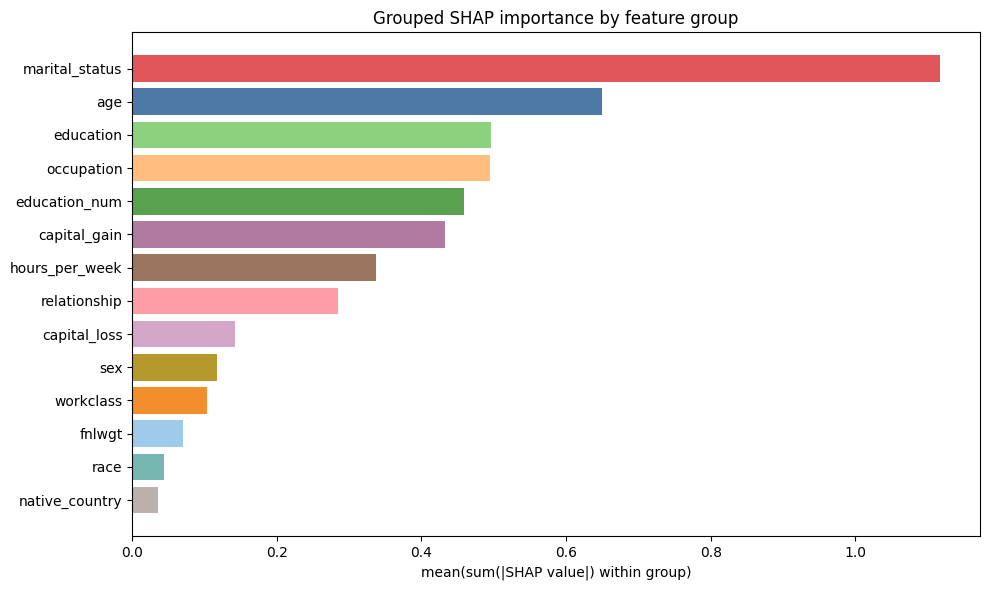

In [12]:
group_bar = group_importance.sort_values(ascending=True)
group_colors = [group_color_map[group_name] for group_name in group_bar.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(group_bar.index, group_bar.values, color=group_colors)
ax.set_title("Grouped SHAP importance by feature group")
ax.set_xlabel("mean(sum(|SHAP value|) within group)")
ax.set_ylabel("")
plt.tight_layout()

## 色分けした通常 SHAP bar plot

通常 SHAP 側も所属グループの色で塗ることで、one-hot 列と群側の対応を追いやすくします。

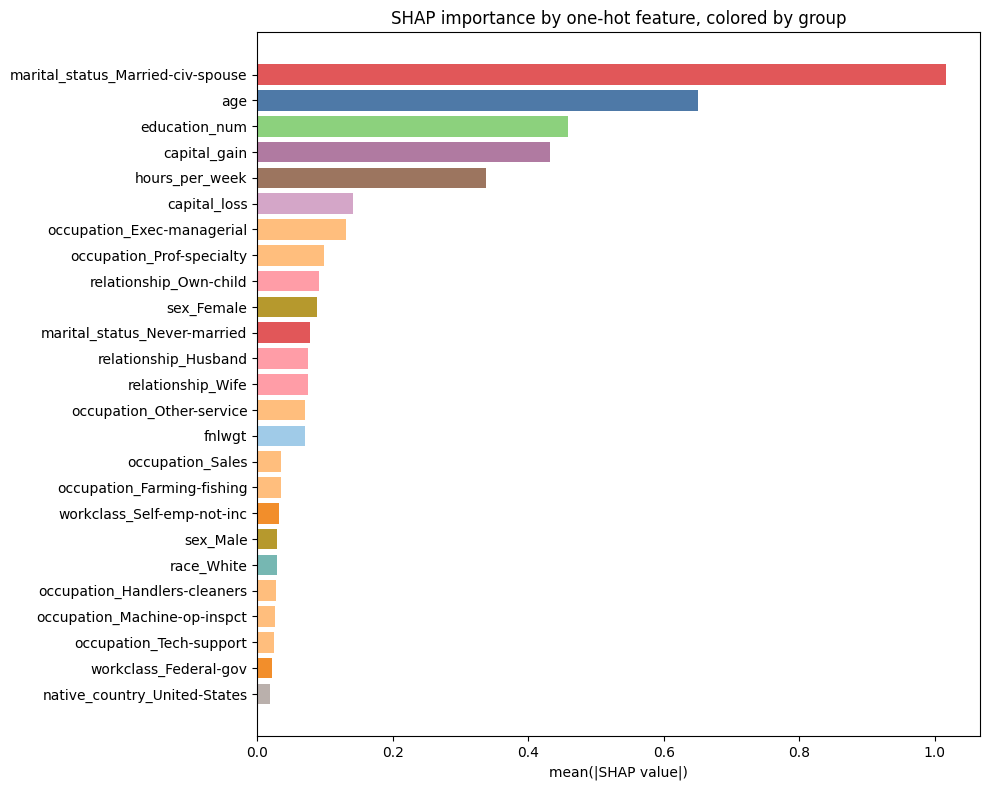

In [13]:
top_feature_bar = feature_importance.head(25).sort_values(ascending=True)
top_feature_colors = [group_color_map[feature_to_group[feature_name]] for feature_name in top_feature_bar.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_feature_bar.index, top_feature_bar.values, color=top_feature_colors)
ax.set_title("SHAP importance by one-hot feature, colored by group")
ax.set_xlabel("mean(|SHAP value|)")
ax.set_ylabel("")
plt.tight_layout()

## PartitionExplainer で groupSHAP を直接近似する

ここでは one-hot 列を後から集約する代わりに、説明時の coalition を元特徴グループ単位に制約します。`feature_groups` は prefix の衝突で `education_num` を巻き込むため、このセクションでは group 定義を重複なしで作り直します。

In [14]:
GROUP_SHAP_BACKGROUND_SIZE = 200
GROUP_SHAP_EXPLAIN_SIZE = 1000
GROUP_SHAP_MAX_EVALS = 500
GROUP_SHAP_BATCH_SIZE = 50
GROUP_SHAP_RANDOM_STATE = 42

group_feature_groups = {col: [col] for col in numeric_cols}
for col in categorical_cols:
    group_feature_groups[col] = [
        encoded_col
        for encoded_col in X_train.columns
        if encoded_col.startswith(f"{col}_") and encoded_col not in numeric_cols
    ]

group_feature_counts = pd.Series({k: len(v) for k, v in group_feature_groups.items()}, name="n_columns")
covered_columns = [col for cols in group_feature_groups.values() for col in cols]

assert len(covered_columns) == len(set(covered_columns)) == X_train.shape[1]
display(group_feature_counts)
print("background size:", min(GROUP_SHAP_BACKGROUND_SIZE, len(X_train)))
print("explain size:", min(GROUP_SHAP_EXPLAIN_SIZE, len(X_test)))

age                1
fnlwgt             1
education_num      1
capital_gain       1
capital_loss       1
hours_per_week     1
workclass          9
education         16
marital_status     7
occupation        15
relationship       6
race               5
sex                2
native_country    42
Name: n_columns, dtype: int64

background size: 200
explain size: 1000


In [15]:
def build_group_linkage(feature_names, feature_groups, within_distance=1.0, between_distance_start=10.0):
    feature_index = {name: i for i, name in enumerate(feature_names)}
    next_node_id = len(feature_names)
    node_sizes = {i: 1 for i in range(len(feature_names))}
    linkage_rows = []
    group_roots = []

    def merge_many(node_ids, distance):
        nonlocal next_node_id
        current = node_ids[0]
        for node_id in node_ids[1:]:
            merged_size = node_sizes[current] + node_sizes[node_id]
            linkage_rows.append([current, node_id, distance, merged_size])
            node_sizes[next_node_id] = merged_size
            current = next_node_id
            next_node_id += 1
        return current

    for group_name, group_columns in feature_groups.items():
        node_ids = [feature_index[col] for col in group_columns]
        if not node_ids:
            raise ValueError(f"group '{group_name}' has no columns")
        root_id = merge_many(node_ids, within_distance) if len(node_ids) > 1 else node_ids[0]
        group_roots.append(root_id)

    current_root = group_roots[0]
    distance = between_distance_start
    for group_root in group_roots[1:]:
        merged_size = node_sizes[current_root] + node_sizes[group_root]
        linkage_rows.append([current_root, group_root, distance, merged_size])
        node_sizes[next_node_id] = merged_size
        current_root = next_node_id
        next_node_id += 1
        distance += 1.0

    return np.asarray(linkage_rows, dtype=float)


group_feature_names = X_train.columns.tolist()
group_feature_index = {name: i for i, name in enumerate(group_feature_names)}
group_linkage = build_group_linkage(group_feature_names, group_feature_groups)

background_group = X_train.sample(
    min(GROUP_SHAP_BACKGROUND_SIZE, len(X_train)),
    random_state=GROUP_SHAP_RANDOM_STATE,
)
X_group_shap = X_test.sample(
    min(GROUP_SHAP_EXPLAIN_SIZE, len(X_test)),
    random_state=GROUP_SHAP_RANDOM_STATE,
)

def predict_proba_positive(data):
    if isinstance(data, pd.DataFrame):
        data_df = data.reindex(columns=group_feature_names)
    else:
        data_df = pd.DataFrame(data, columns=group_feature_names)
    return baseline_model.predict_proba(data_df)[:, 1]


group_masker = shap.maskers.Partition(background_group, clustering=group_linkage)
group_explainer = shap.Explainer(
    predict_proba_positive,
    masker=group_masker,
    algorithm="partition",
    feature_names=group_feature_names,
)
group_shap_detail = group_explainer(
    X_group_shap,
    max_evals=GROUP_SHAP_MAX_EVALS,
    batch_size=GROUP_SHAP_BATCH_SIZE,
)

group_phi = pd.DataFrame(
    {
        group_name: group_shap_detail.values[:, [group_feature_index[col] for col in cols]].sum(axis=1)
        for group_name, cols in group_feature_groups.items()
    },
    index=X_group_shap.index,
)

group_shap_importance = group_phi.abs().mean().sort_values(ascending=False)
group_sum_abs_approx = pd.Series(
    {
        group_name: np.abs(
            shap_values.values[X_group_shap.index][:, [X_shap.columns.get_loc(col) for col in cols]].sum(axis=1)
        ).mean()
        for group_name, cols in group_feature_groups.items()
    },
    name="mean_abs_group_sum_from_tree_shap",
).sort_values(ascending=False)

group_comparison = pd.concat(
    [
        group_shap_importance.rename("mean_abs_group_shap"),
        group_sum_abs_approx,
    ],
    axis=1,
)

display(group_comparison)
print("group linkage shape:", group_linkage.shape)
print("group SHAP leaf matrix:", group_shap_detail.values.shape)
print("group phi matrix:", group_phi.shape)
print(
    "max additive residual:",
    np.max(np.abs(group_phi.sum(axis=1).values - group_shap_detail.values.sum(axis=1))),
)

PartitionExplainer explainer: 1001it [08:32,  1.92it/s]                          


,mean_abs_group_shap,mean_abs_group_sum_from_tree_shap
marital_status,0.097692,1.082493
workclass,0.038883,0.065156
occupation,0.031954,0.313267
hours_per_week,0.017135,0.337696
fnlwgt,0.017133,0.068866
age,0.017133,0.668984
education_num,0.017133,0.447410
capital_gain,0.017133,0.471888
capital_loss,0.017133,0.133967
relationship,0.016939,0.214462


group linkage shape: (107, 4)
group SHAP leaf matrix: (1000, 108)
group phi matrix: (1000, 14)
max additive residual: 4.440892098500626e-16


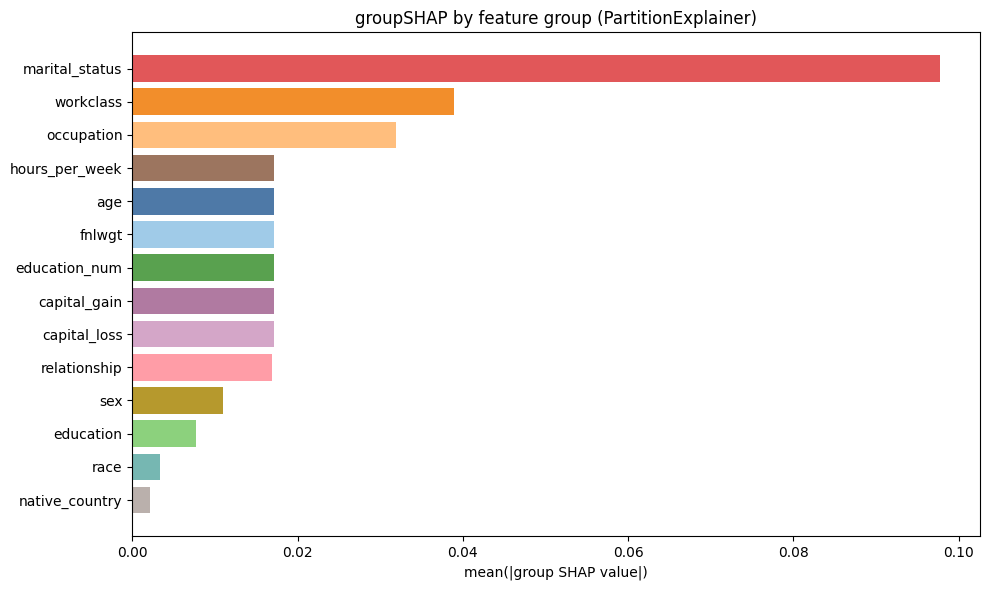

In [16]:
group_bar_exact = group_shap_importance.sort_values(ascending=True)
group_colors_exact = [group_color_map[group_name] for group_name in group_bar_exact.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(group_bar_exact.index, group_bar_exact.values, color=group_colors_exact)
ax.set_title("groupSHAP by feature group (PartitionExplainer)")
ax.set_xlabel("mean(|group SHAP value|)")
ax.set_ylabel("")
plt.tight_layout()

## 色分けした通常 SHAP signed bar plot

one-hot 列ごとの平均 SHAP 値を符号付きで集計し、0 を中心に左右へ伸びる bar plot として表示します。色は既存の通常 SHAP bar plot と同じく所属グループで塗り分けます。

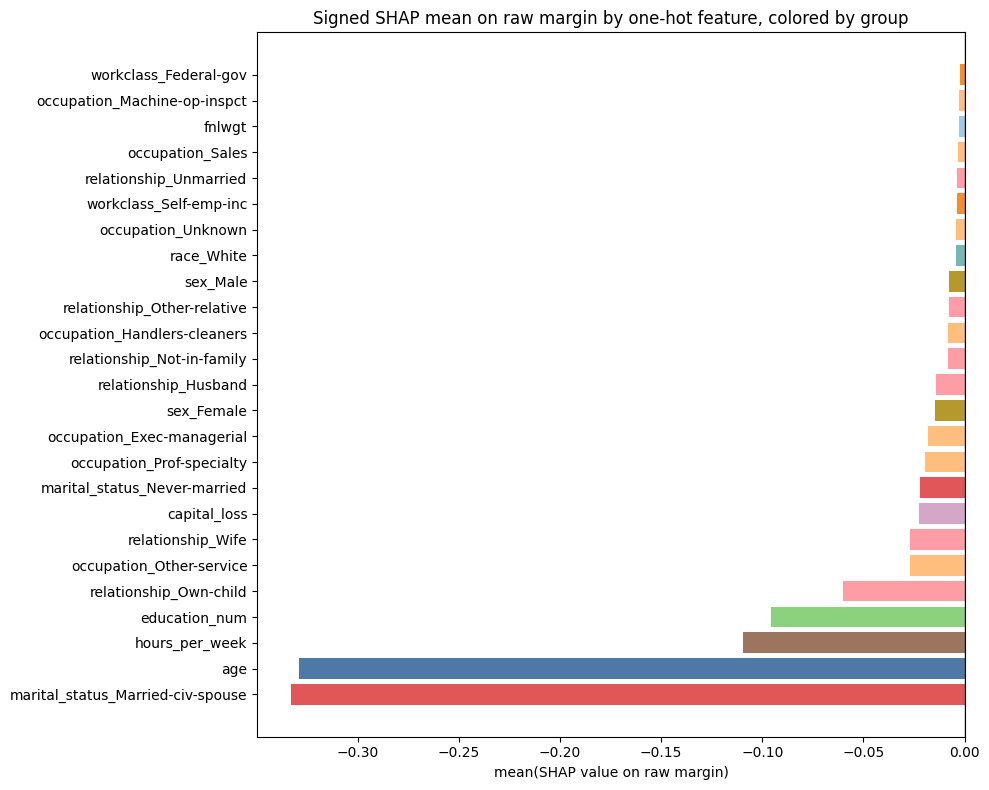

In [17]:
signed_feature_importance = pd.Series(
    shap_values.values.mean(axis=0),
    index=X_shap.columns,
    name="mean_shap",
)

top_signed_feature_bar = signed_feature_importance.reindex(
    signed_feature_importance.abs().sort_values(ascending=False).head(25).index
).sort_values()
top_signed_feature_colors = [group_color_map[feature_to_group[feature_name]] for feature_name in top_signed_feature_bar.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_signed_feature_bar.index, top_signed_feature_bar.values, color=top_signed_feature_colors)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_title("Signed SHAP mean on raw margin by one-hot feature, colored by group")
ax.set_xlabel("mean(SHAP value on raw margin)")
ax.set_ylabel("")
plt.tight_layout()

In [18]:
print("expected_value:", explainer.expected_value)
print("first prediction raw sum:", explainer.expected_value + shap_values.values[0].sum())
print("model raw output (approx):", baseline_model.predict(X_shap.iloc[[0]], output_margin=True)[0])


expected_value: -1.1655049
first prediction raw sum: -5.8539686
model raw output (approx): -5.8539686


## 簡単な OLS 係数の可視化

`statsmodels` は入っていないので、`sklearn.linear_model.LinearRegression` で OLS 相当の線形回帰を当てます。`y` は 0/1 なので、ここでは線形確率モデルとして係数の向きをざっくり確認します。

relationship_Wife                            0.190655
native_country_Cambodia                      0.167094
native_country_Holand-Netherlands           -0.143475
workclass_Without-pay                       -0.134734
native_country_Outlying-US(Guam-USVI-etc)   -0.132514
occupation_Armed-Forces                     -0.131329
occupation_Exec-managerial                   0.130874
marital_status_Married-AF-spouse             0.130272
occupation_Farming-fishing                  -0.101398
education_Doctorate                          0.099960
native_country_France                        0.098743
workclass_Federal-gov                        0.094890
native_country_Italy                         0.093790
education_Preschool                          0.085676
education_Assoc-acdm                        -0.084458
relationship_Not-in-family                  -0.084050
workclass_Self-emp-inc                       0.083034
native_country_Yugoslavia                    0.082937
native_country_Japan        

intercept: -0.34768535286206403
train R^2: 0.3691026868915954
test R^2: 0.3616326153249705


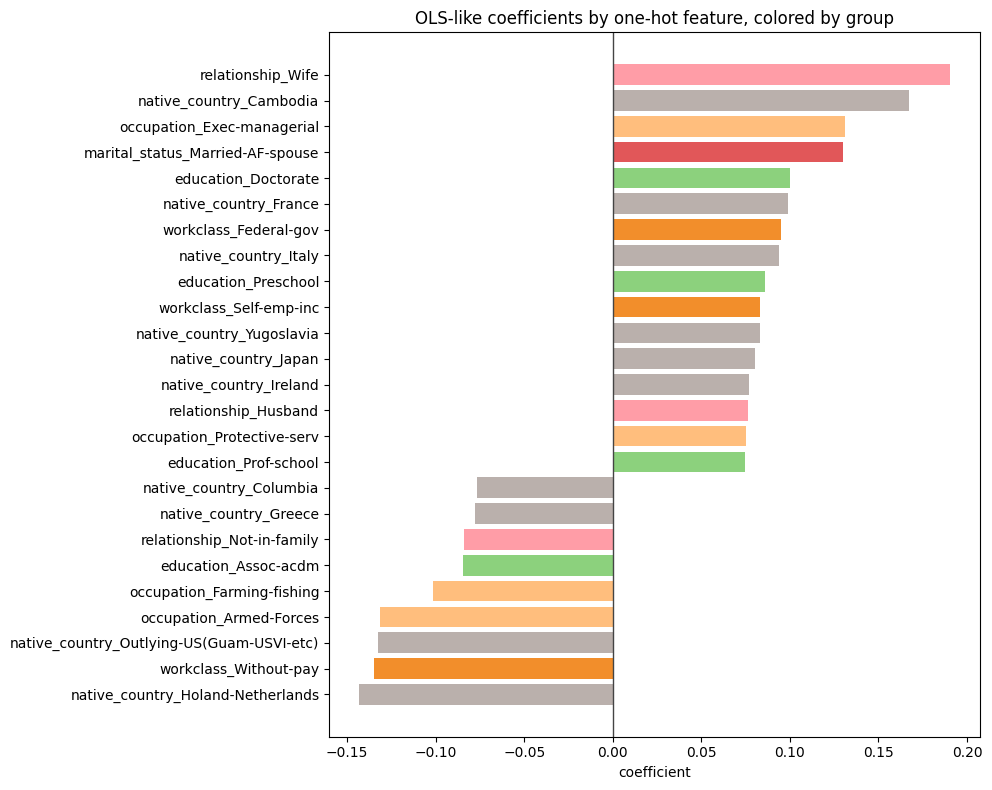

In [19]:
from sklearn.linear_model import LinearRegression

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

ols_coef = pd.Series(
    ols_model.coef_,
    index=X_train.columns,
    name="ols_coef",
)

top_ols_coef = ols_coef.reindex(ols_coef.abs().sort_values(ascending=False).head(25).index).sort_values()
top_ols_colors = [group_color_map[feature_to_group[feature_name]] for feature_name in top_ols_coef.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_ols_coef.index, top_ols_coef.values, color=top_ols_colors)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_title("OLS-like coefficients by one-hot feature, colored by group")
ax.set_xlabel("coefficient")
ax.set_ylabel("")
plt.tight_layout()

display(ols_coef.sort_values(key=lambda s: s.abs(), ascending=False).head(20))
print("intercept:", ols_model.intercept_)
print("train R^2:", ols_model.score(X_train, y_train))
print("test R^2:", ols_model.score(X_test, y_test))